# Requirement 1: Single Campaign, Stochastic

First-price single-slot auction, one campaign, i.i.d. competing bids $m_t \sim \text{Beta}(k, 1)$
(= max of $k$ independent Uniform(0,1) bids).

**Algorithm A** — UCB1 over the bid grid, no budget constraint.  
**Algorithm B** — UCBLike: UCB on utility + LCB on cost, LP mixed strategy, budget-aware.

Clairvoyant A: best fixed bid $b^* = \arg\max_b (v-b)\,\mathbb{P}(m \le b)$.  
Clairvoyant B: LP over mixed bid strategies subject to $\mathbb{E}[\text{cost}] \le \rho$.

In [1]:
import sys, os

# Resolve repo root whether notebook is run from repo root or notebooks/
repo_root = os.path.abspath('.')
if not os.path.isdir(os.path.join(repo_root, 'src')):
    repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import matplotlib.pyplot as plt

from src.core.stochastic_env import SingleCampaignEnv
from src.core.ucb_bidder import UCB1BidderAgent, UCBLikeBidderAgent
from src.core.clairvoyant import (
    win_probs_beta_uniform,
    clairvoyant_no_budget,
    clairvoyant_with_budget,
)
from src.utils.runner import run_trials
from src.utils.regret import summarise_regret
from src.utils.plotting import new_figure, plot_regret, plot_budget_consumption, save_figure

FIGURES_DIR = os.path.join(repo_root, 'report', 'figures')

In [2]:
# ── Experiment parameters ─────────────────────────────────────────────────────
# Seeds stored in data/seeds/
SEED_A = 1001   # master seed — Algorithm A experiments
SEED_B = 2002   # master seed — Algorithm B experiments

value    = 1.5    # private value v
K        = 5      # bid grid size
T        = 10000  # horizon
n_comp   = 3      # competing advertisers → m_t ~ Beta(3, 1)
n_trials = 20     # independent trials for regret estimation

rho_tight = 0.01  # binding per-round budget
rho_loose = 1.5  # non-binding per-round budget

bid_grid  = np.linspace(0.0, value, K)       # bid_grid[0] = 0 (opt-out)
win_probs = win_probs_beta_uniform(bid_grid, n_comp)

print(f'Bid grid (K={K}):   {bid_grid.round(3)}')
print(f'Win probabilities: {win_probs.round(3)}')

Bid grid (K=5):   [0.    0.375 0.75  1.125 1.5  ]
Win probabilities: [0.    0.053 0.422 1.424 3.375]


In [4]:
# ── Clairvoyant baselines ─────────────────────────────────────────────────────
best_bid_A, reward_A   = clairvoyant_no_budget(bid_grid, value, win_probs)
_, reward_Bt, cost_Bt  = clairvoyant_with_budget(bid_grid, value, rho_tight, win_probs)
_, reward_Bl, cost_Bl  = clairvoyant_with_budget(bid_grid, value, rho_loose, win_probs)

print(f'Clairvoyant A (no budget):       best_bid={best_bid_A:.3f},  reward/round={reward_A:.5f}')
print(f'Clairvoyant B tight (ρ={rho_tight}):  reward/round={reward_Bt:.5f},  cost/round={cost_Bt:.5f}')
print(f'Clairvoyant B loose (ρ={rho_loose}):  reward/round={reward_Bl:.5f},  cost/round={cost_Bl:.5f}')
print()
if abs(reward_A - reward_Bl) < 1e-4:
    print('ρ_loose is non-binding — budget clairvoyant matches no-budget clairvoyant.')
else:
    print(f'ρ_loose is binding — budget clairvoyant is {100*(reward_A-reward_Bl)/reward_A:.1f}% below no-budget.')

Clairvoyant A (no budget):       best_bid=1.125,  reward/round=0.53394
Clairvoyant B tight (ρ=0.01):  reward/round=0.03000,  cost/round=0.01000
Clairvoyant B loose (ρ=1.5):  reward/round=0.51671,  cost/round=1.50000

ρ_loose is binding — budget clairvoyant is 3.2% below no-budget.


## Experiments

In [5]:
# ── Algorithm A: UCB1, no budget ──────────────────────────────────────────────
env_A   = SingleCampaignEnv(value=value, T=T, n_competitors=n_comp)
agent_A = UCB1BidderAgent(bid_grid=bid_grid, value=value, T=T)
res_A   = run_trials(env_A, agent_A, T=T, n_trials=n_trials,
                     master_seed=SEED_A, clairvoyant_reward=reward_A)
mean_A, std_A = summarise_regret(res_A['regret_matrix'])

print(f'UCB1 (no budget) — regret at T={T}: {mean_A[-1]:.2f} ± {std_A[-1]/np.sqrt(n_trials):.2f}')
print(f'  Mean total spend: {res_A["cost_matrix"].sum(axis=1).mean():.2f}  (unconstrained)')

UCB1 (no budget) — regret at T=10000: 1961.22 ± 1.21
  Mean total spend: 8979.54  (unconstrained)


In [6]:
# ── Algorithm B: UCBLike, tight budget ────────────────────────────────────────
budget_tight = rho_tight * T
env_Bt       = SingleCampaignEnv(value=value, T=T, n_competitors=n_comp)
agent_Bt     = UCBLikeBidderAgent(bid_grid=bid_grid, value=value,
                                   budget=budget_tight, T=T)
res_Bt       = run_trials(env_Bt, agent_Bt, T=T, n_trials=n_trials,
                          master_seed=SEED_B, clairvoyant_reward=reward_Bt)
mean_Bt, std_Bt = summarise_regret(res_Bt['regret_matrix'])

max_spend_t = res_Bt['cost_matrix'].sum(axis=1).max()
print(f'UCBLike tight (ρ={rho_tight}) — regret: {mean_Bt[-1]:.2f} ± {std_Bt[-1]/np.sqrt(n_trials):.2f}')
print(f'  Budget never violated: {max_spend_t <= budget_tight + 1e-6}  '
      f'(max spend: {max_spend_t:.2f} / {budget_tight:.1f})')

UCBLike tight (ρ=0.01) — regret: 160.12 ± 1.11
  Budget never violated: True  (max spend: 99.75 / 100.0)


In [7]:
# ── Algorithm B: UCBLike, loose budget ────────────────────────────────────────
budget_loose = rho_loose * T
env_Bl       = SingleCampaignEnv(value=value, T=T, n_competitors=n_comp)
agent_Bl     = UCBLikeBidderAgent(bid_grid=bid_grid, value=value,
                                   budget=budget_loose, T=T)
res_Bl       = run_trials(env_Bl, agent_Bl, T=T, n_trials=n_trials,
                          master_seed=SEED_B, clairvoyant_reward=reward_Bl)
mean_Bl, std_Bl = summarise_regret(res_Bl['regret_matrix'])

max_spend_l = res_Bl['cost_matrix'].sum(axis=1).max()
print(f'UCBLike loose (ρ={rho_loose}) — regret: {mean_Bl[-1]:.2f} ± {std_Bl[-1]/np.sqrt(n_trials):.2f}')
print(f'  Budget never violated: {max_spend_l <= budget_loose + 1e-6}  '
      f'(max spend: {max_spend_l:.2f} / {budget_loose:.1f})')

UCBLike loose (ρ=1.5) — regret: 1778.94 ± 4.27
  Budget never violated: True  (max spend: 8976.38 / 15000.0)


## Results

Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req1_regret.png


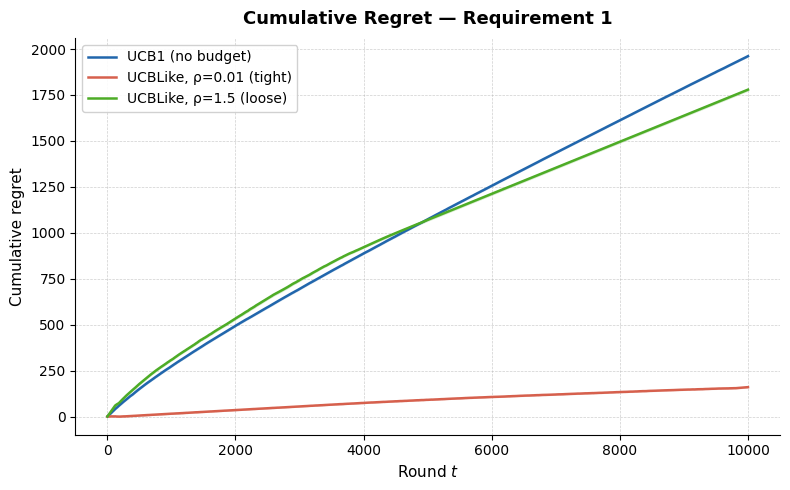

In [8]:
# ── Regret curves ─────────────────────────────────────────────────────────────
fig, ax = new_figure('Cumulative Regret — Requirement 1')
plot_regret(ax, mean_A,  std_A,  n_trials=n_trials, label='UCB1 (no budget)')
plot_regret(ax, mean_Bt, std_Bt, n_trials=n_trials, label=f'UCBLike, ρ={rho_tight} (tight)')
plot_regret(ax, mean_Bl, std_Bl, n_trials=n_trials, label=f'UCBLike, ρ={rho_loose} (loose)')
save_figure(fig, os.path.join(FIGURES_DIR, 'req1_regret.png'))
plt.show()

Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req1_budget.png


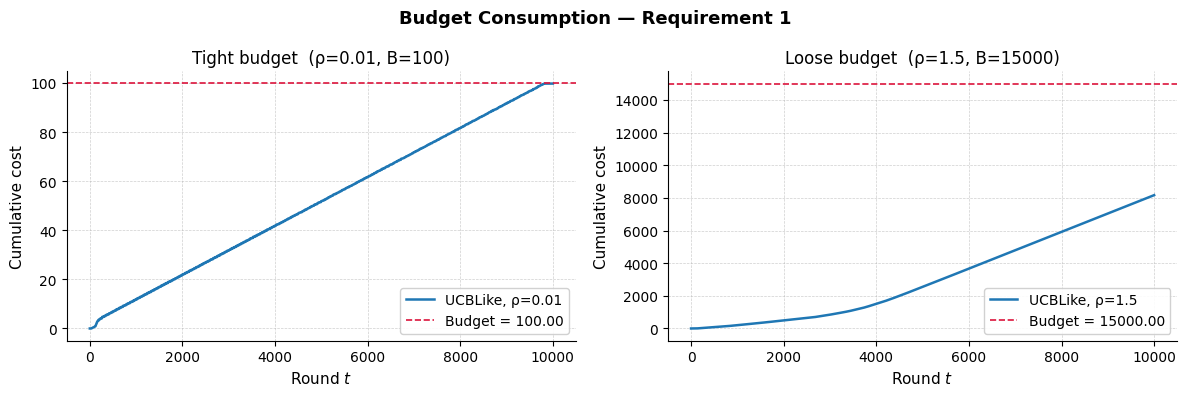

In [9]:
# ── Budget consumption ────────────────────────────────────────────────────────
mean_cumcost_t = res_Bt['cost_matrix'].cumsum(axis=1).mean(axis=0)
mean_cumcost_l = res_Bl['cost_matrix'].cumsum(axis=1).mean(axis=0)

fig2, (ax_t, ax_l) = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle('Budget Consumption — Requirement 1', fontsize=13, fontweight='bold')
plot_budget_consumption(ax_t, mean_cumcost_t, budget_tight,
                        label=f'UCBLike, ρ={rho_tight}')
plot_budget_consumption(ax_l, mean_cumcost_l, budget_loose,
                        label=f'UCBLike, ρ={rho_loose}')
ax_t.set_title(f'Tight budget  (ρ={rho_tight}, B={budget_tight:.0f})')
ax_l.set_title(f'Loose budget  (ρ={rho_loose}, B={budget_loose:.0f})')
save_figure(fig2, os.path.join(FIGURES_DIR, 'req1_budget.png'))
plt.show()

## Regret Scaling with $T$

Run both algorithms at several horizon lengths.  
A sublinear algorithm's final regret should grow slower than $O(T)$.

In [10]:
# ── Vary T ────────────────────────────────────────────────────────────────────
T_list   = [500, 1000, 2000, 4000, 6000, 8000, 10000]
final_A  = []
final_Bt = []
final_Bl = []

for T_val in T_list:
    bg_ = np.linspace(0.0, 1.0, K)
    wp_ = win_probs_beta_uniform(bg_, n_comp)
    _, rA     = clairvoyant_no_budget(bg_, value, wp_)
    _, rBt, _ = clairvoyant_with_budget(bg_, value, rho_tight, wp_)
    _, rBl, _ = clairvoyant_with_budget(bg_, value, rho_loose, wp_)

    e1 = SingleCampaignEnv(value=value, T=T_val, n_competitors=n_comp)
    a1 = UCB1BidderAgent(bid_grid=bg_, value=value, T=T_val)
    r1 = run_trials(e1, a1, T=T_val, n_trials=n_trials,
                    master_seed=SEED_A, clairvoyant_reward=rA)
    final_A.append(summarise_regret(r1['regret_matrix'])[0][-1])

    e2 = SingleCampaignEnv(value=value, T=T_val, n_competitors=n_comp)
    a2 = UCBLikeBidderAgent(bid_grid=bg_, value=value,
                             budget=rho_tight * T_val, T=T_val)
    r2 = run_trials(e2, a2, T=T_val, n_trials=n_trials,
                    master_seed=SEED_B, clairvoyant_reward=rBt)
    final_Bt.append(summarise_regret(r2['regret_matrix'])[0][-1])

    e3 = SingleCampaignEnv(value=value, T=T_val, n_competitors=n_comp)
    a3 = UCBLikeBidderAgent(bid_grid=bg_, value=value,
                             budget=rho_loose * T_val, T=T_val)
    r3 = run_trials(e3, a3, T=T_val, n_trials=n_trials,
                    master_seed=SEED_B, clairvoyant_reward=rBl)
    final_Bl.append(summarise_regret(r3['regret_matrix'])[0][-1])

    print(f'T={T_val:5d}: UCB1={final_A[-1]:.1f},  tight={final_Bt[-1]:.1f},  loose={final_Bl[-1]:.1f}')


T=  500: UCB1=81.7,  tight=7.1,  loose=161.9
T= 1000: UCB1=126.0,  tight=16.0,  loose=183.8
T= 2000: UCB1=181.8,  tight=35.5,  loose=202.2
T= 4000: UCB1=243.8,  tight=75.0,  loose=221.4
T= 6000: UCB1=281.2,  tight=109.5,  loose=232.0
T= 8000: UCB1=310.0,  tight=140.6,  loose=238.8
T=10000: UCB1=331.2,  tight=172.4,  loose=245.6


Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req1_scaling.png


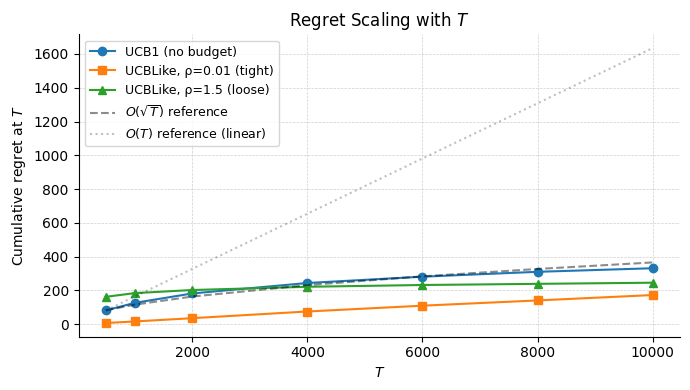

In [11]:
# ── Scaling plot ──────────────────────────────────────────────────────────────
T_arr = np.array(T_list, dtype=float)
T0    = T_arr[0]

fig3, ax3 = plt.subplots(figsize=(7, 4))
ax3.plot(T_list, final_A,  'o-', label='UCB1 (no budget)')
ax3.plot(T_list, final_Bt, 's-', label=f'UCBLike, ρ={rho_tight} (tight)')
ax3.plot(T_list, final_Bl, '^-', label=f'UCBLike, ρ={rho_loose} (loose)')
ax3.plot(T_arr, final_A[0]  * np.sqrt(T_arr / T0), 'k--', alpha=0.45,
         label=r'$O(\sqrt{T})$ reference')
ax3.plot(T_arr, final_A[0]  * (T_arr / T0),         'k:',  alpha=0.25,
         label=r'$O(T)$ reference (linear)')
ax3.set_xlabel('$T$')
ax3.set_ylabel('Cumulative regret at $T$')
ax3.set_title('Regret Scaling with $T$')
ax3.legend(fontsize=9)
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
save_figure(fig3, os.path.join(FIGURES_DIR, 'req1_scaling.png'))
plt.show()

## Discussion

**When the budget is tight (ρ = 0.05):**  
The LP clairvoyant is strictly worse than the no-budget clairvoyant — it is forced to bid more
conservatively to pace spending.  UCBLike must also pace, so it will win fewer auctions than
UCB1. Regret is measured against the *appropriate* constrained clairvoyant, so the curves are
comparable in scale.

**When the budget is loose (ρ = 0.30):**  
The budget constraint is non-binding: the LP clairvoyant picks the same bid as the
no-budget clairvoyant. UCBLike degenerates to roughly UCB1 behaviour (the LP constraint
is trivially satisfied), so both regret curves should be close.

**Sublinear regret:**  
UCB1 theory guarantees $O(K \log T)$ instance-dependent regret and $O(\sqrt{KT \log T})$
minimax regret. The scaling plot should show growth well below $O(T)$.  
UCBLike has the same UCB confidence widths, so a similar asymptotic behaviour is expected
in the stochastic setting (though the LP overhead increases constants).

**Budget safety:**  
UCBLike guarantees budget is never exceeded because it uses *pessimistic* cost estimates
(LCB), ensuring its LP constraint is at least as tight as the true expected cost.